# Trace-level performance by prefix length — all 4 PPM approaches

**Scope**: synthetic (`none` trim, 10 datasets), real-life (`ssd` trim, 8 datasets).

In [1]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

ROOT = Path(".").resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT.parent))
sys.path.insert(0, str(ROOT.parent / "plain-field"))

import numpy as np
import pandas as pd
import pm4py
import matplotlib.pyplot as plt

import error_direction as ed
from ts_comparison import load_splits, load_ppm_raw_predictions, _read_csv_safe_caseid, _camargo_summary_and_trim_dir, GLSTM, _rem_time_to_event_log
from run_predictions_real import _make_half_prefix_test_df
from runner import get_inflight_cases
from time_series_creation import create_concurrent_cases_timeseries, create_avg_throughtput_time_timeseries
from sklearn.metrics import mean_absolute_error


get_ipython().run_line_magic("matplotlib", "inline")

RESULTS = ROOT.parent / "results"
BEST = ROOT.parent / "best_models"
DATA = ROOT.parent / "data"

SYNTH_DATASETS = list(ed.synth_logs)
REAL_DATASETS = list(ed.real_logs)
REMTIME_MODELS = ["amiri", "bukhsh_rt"]
SUFFIX_MODELS = ["bukhsh_suffix", "camargo"]
MODELS = REMTIME_MODELS + SUFFIX_MODELS
REGIMES = ["full", "half", "plain_field"]
print(f"{len(SYNTH_DATASETS)} synthetic (none), {len(REAL_DATASETS)} real-life (ssd)")


10 synthetic (none), 8 real-life (ssd)


## 1. Prefix length per case, per regime — independently reconstructed

In [2]:
def prefix_lens_for_regime(dataset, regime, is_real):
    trim = "ssd" if is_real else "none"
    split = load_splits(dataset, trim, is_real)
    df_full, test_df, val_split = split["df"], split["test"], split["cc"]["val_split"]

    if regime == "full":
        pl = test_df.groupby("caseid").size()
    elif regime == "half":
        half_df = _make_half_prefix_test_df(df_full, test_df)
        pl = half_df.groupby("caseid").size()
    elif regime == "plain_field":
        inflight_df = get_inflight_cases(df_full, val_split, case_col="caseid", time_col="end_timestamp")
        pl = inflight_df.groupby("caseid").size()
        # SOS cases (pf_0, pf_1, ...) are prefix_len=1 by construction -- not
        # present in df_full at all (they're simulated), so added separately
        # once we know which SOS caseids actually appear in a given model's
        # predictions (done at the per-model join step below, not here).
    else:
        raise ValueError(regime)

    pl.index = pl.index.astype(str)
    return pl.rename("prefix_len")


## 1b. Case origin — fresh vs. in-flight, independent of regime


In [3]:
_case_origin_cache = {}


def case_origin_for_dataset(dataset, is_real):
    """caseid (str) -> 'fresh' | 'in-flight' | NaN, for every REAL case in the
    full log (not synthetic SOS pseudo-cases -- those are assigned 'fresh'
    directly at the call site).
    """
    key = (dataset, is_real)
    if key in _case_origin_cache:
        return _case_origin_cache[key]
    trim = "ssd" if is_real else "none"
    split = load_splits(dataset, trim, is_real)
    df_full, val_split = split["df"], split["cc"]["val_split"]

    case_min = df_full.groupby("caseid")["end_timestamp"].min()
    case_max = df_full.groupby("caseid")["end_timestamp"].max()
    case_min.index = case_min.index.astype(str)
    case_max.index = case_max.index.astype(str)

    origin = pd.Series(np.nan, index=case_min.index, dtype=object, name="case_origin")
    origin[case_min > val_split] = "fresh"
    origin[(case_min <= val_split) & (case_max > val_split)] = "in-flight"
    _case_origin_cache[key] = origin
    return origin


## 1c. How long are test prefixes, actually? Distribution, and how it shifts over the test horizon


In [ ]:
def prefix_len_distribution_table(datasets, is_real):
    rows = []
    for ds in datasets:
        for regime in ["full", "half"]:
            pl = prefix_lens_for_regime(ds, regime, is_real)
            for length, count in pl.value_counts().items():
                rows.append(dict(dataset=ds, regime=regime, prefix_len=length, n_cases=count))
    return pd.DataFrame(rows)


prefix_len_dist = pd.concat([
    prefix_len_distribution_table(SYNTH_DATASETS, False),
    prefix_len_distribution_table(REAL_DATASETS, True),
], ignore_index=True)
prefix_len_dist.sort_values(["dataset", "regime", "prefix_len"]).head(20)


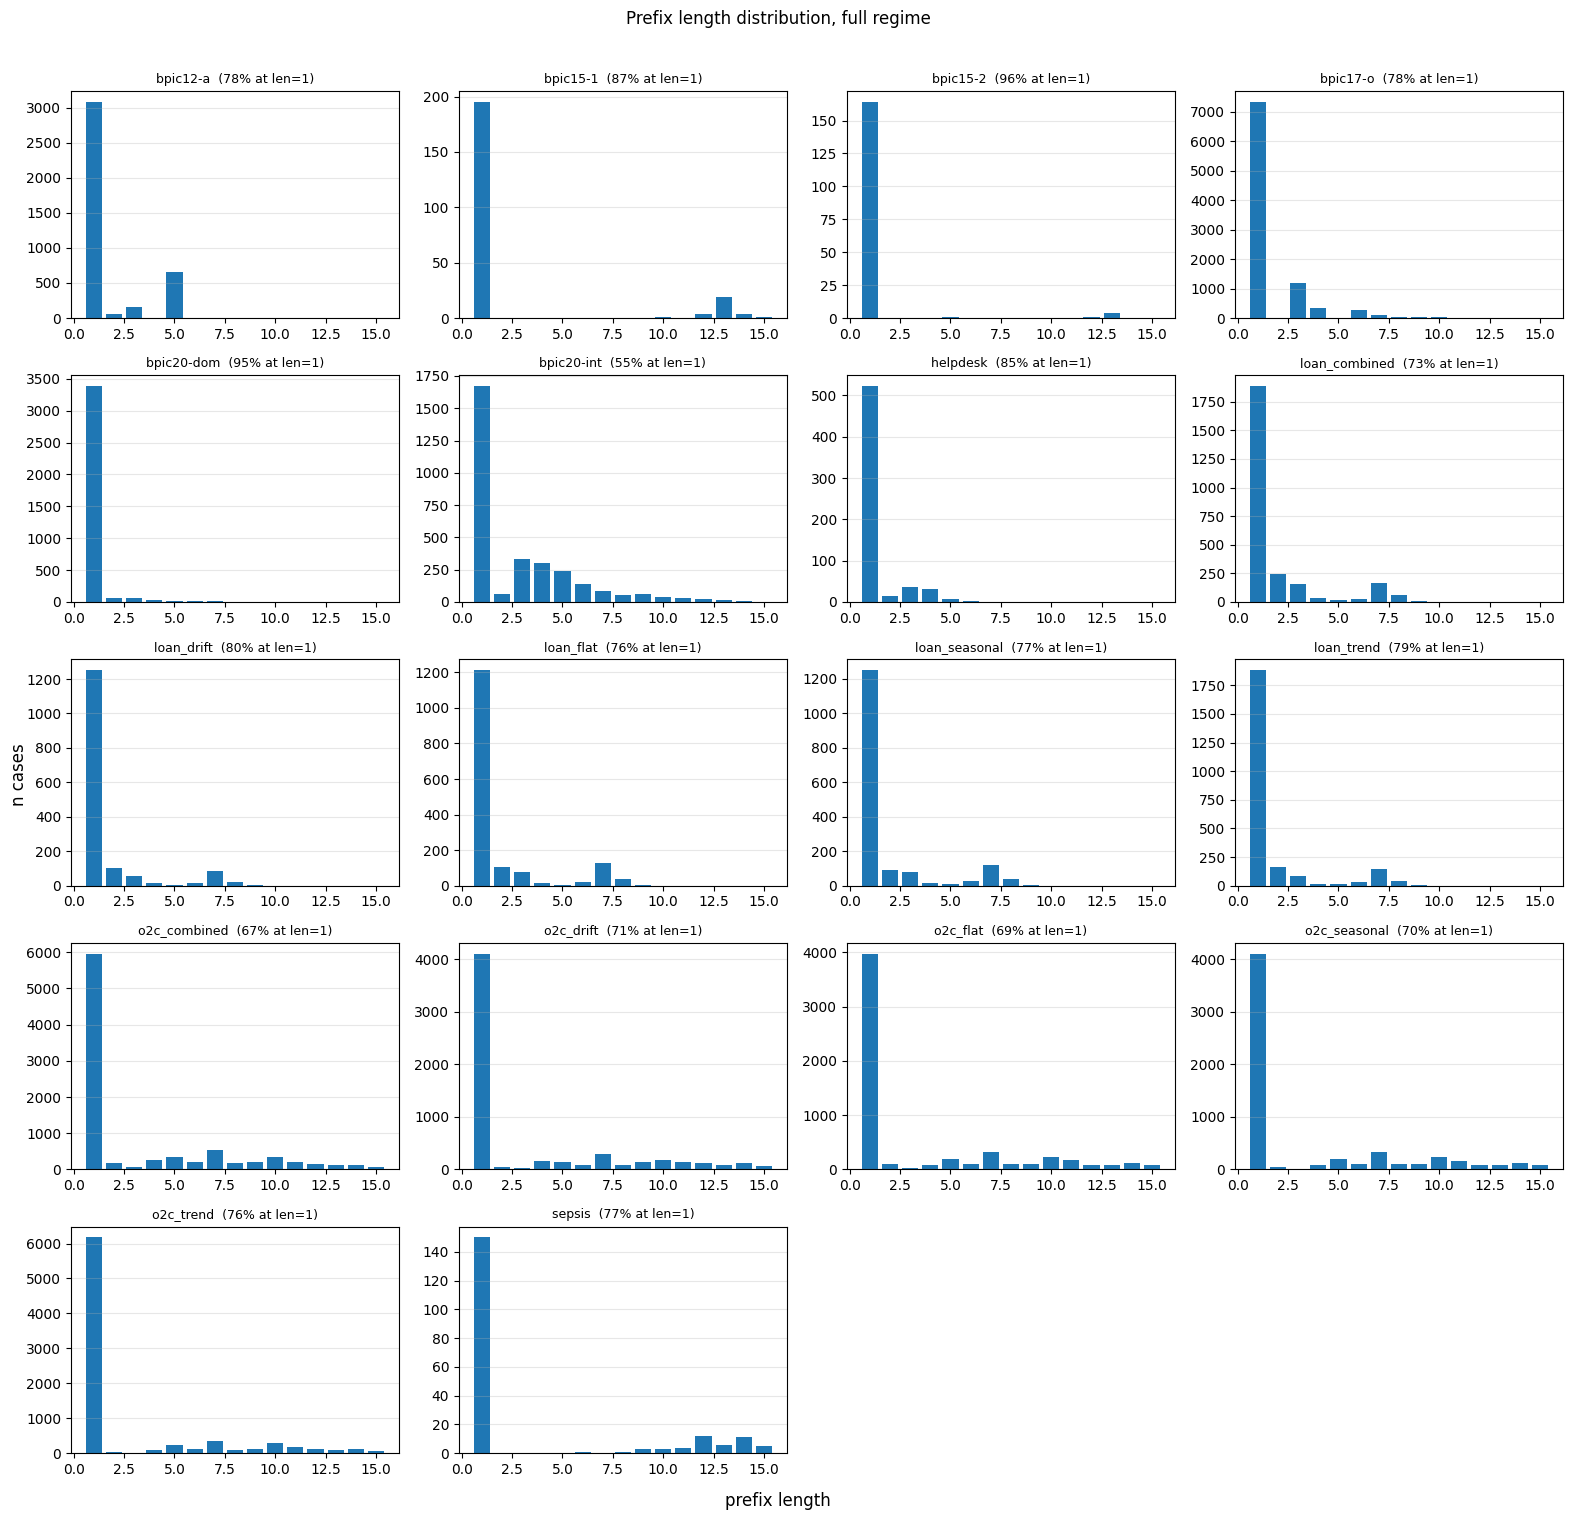

In [5]:
def plot_prefix_len_distribution_grid(table, regime="full", max_prefix_len=15, ncols=4):
    sub_all = table[(table["regime"] == regime) & (table["prefix_len"] <= max_prefix_len)]
    datasets_present = sorted(sub_all["dataset"].unique())
    n = len(datasets_present)
    nrows = -(-n // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    axes = axes.flatten()
    for ax, ds in zip(axes, datasets_present):
        sub = sub_all[sub_all["dataset"] == ds].set_index("prefix_len")["n_cases"].reindex(range(1, max_prefix_len + 1), fill_value=0)
        pct1 = sub.loc[1] / sub.sum() * 100 if sub.sum() else 0
        ax.bar(sub.index, sub.values, color="C0")
        ax.set_title(f"{ds}  ({pct1:.0f}% at len=1)", fontsize=9)
        ax.grid(alpha=0.3, axis="y")
    for ax in axes[n:]:
        ax.axis("off")
    fig.supxlabel("prefix length")
    fig.supylabel("n cases")
    fig.suptitle(f"Prefix length distribution, {regime} regime", y=1.01)
    plt.tight_layout()
    plt.show()


plot_prefix_len_distribution_grid(prefix_len_dist, regime="full")


### Prefix length over the test horizon (full regime) — does the mix shift as the warm-up section predicts?

In [ ]:
def prefix_len_over_time_table(datasets, is_real, max_weeks=8):
    rows = []
    trim = "ssd" if is_real else "none"
    for ds in datasets:
        split = load_splits(ds, trim, is_real)
        df_full, val_split = split["df"], split["cc"]["val_split"]
        pl_full = prefix_lens_for_regime(ds, "full", is_real)

        case_max = df_full.groupby("caseid")["end_timestamp"].max()
        case_max.index = case_max.index.astype(str)
        case_max_naive = case_max.dt.tz_localize(None) if case_max.dt.tz is not None else case_max
        completion_day = case_max_naive.dt.floor("D")

        vs_naive = pd.Timestamp(val_split)
        if vs_naive.tzinfo is not None:
            vs_naive = vs_naive.tz_localize(None)

        df = pd.DataFrame({"prefix_len": pl_full, "completion_day": completion_day.reindex(pl_full.index)}).dropna()
        test_window = df[df["completion_day"] >= vs_naive]
        if test_window.empty:
            continue
        weeks = (test_window["completion_day"] - vs_naive).dt.days // 7
        by_week = test_window.groupby(weeks)["prefix_len"].agg(["mean", "median", "count"])
        by_week = by_week[by_week.index <= max_weeks]
        for wk, row in by_week.iterrows():
            rows.append(dict(dataset=ds, week=int(wk), mean_prefix_len=row["mean"],
                             median_prefix_len=row["median"], n=int(row["count"])))
    return pd.DataFrame(rows)


prefix_len_over_time = pd.concat([
    prefix_len_over_time_table(SYNTH_DATASETS, False),
    prefix_len_over_time_table(REAL_DATASETS, True),
], ignore_index=True)
prefix_len_over_time.sort_values(["dataset", "week"]).head(20)


## Remaining-time family (amiri, bukhsh_rt) — predicted vs. true remaining time, per case

In [8]:
def _amiri_base_dir(dataset, trim, is_real):
    return (BEST / dataset / trim / "amiri" / f"{dataset}_full") if is_real \
        else (BEST / dataset / "amiri" / "none" / f"{dataset}_full")


def _bukhsh_base_dir(dataset, trim, is_real):
    return (BEST / dataset / trim / "bukhsh" / f"{dataset}_test_full") if is_real \
        else (BEST / dataset / "bukhsh" / f"{dataset}_test_full")


_REGIME_SUBDIR = {"plain_field": "pf", "half": "half_prefix", "full": None}


def _rem_time_path(base_dir, regime):
    sub = _REGIME_SUBDIR[regime]
    return (base_dir / sub / "rem_time.csv") if sub else (base_dir / "rem_time.csv")


def load_direct_remtime(model, dataset, regime, is_real):
    """amiri / bukhsh_rt raw rem_time.csv, keeping prefix_len this time."""
    trim = "ssd" if is_real else "none"
    base = _amiri_base_dir(dataset, trim, is_real) if model == "amiri" else _bukhsh_base_dir(dataset, trim, is_real)
    p = _rem_time_path(base, regime)
    if not p.exists():
        return None
    df = _read_csv_safe_caseid(p)
    df["anchor_timestamp"] = pd.to_datetime(df["anchor_timestamp"], utc=True, format="mixed")
    df["predicted_end"] = df["anchor_timestamp"] + pd.to_timedelta(df["rem_time_days"].astype(float), unit="D")
    df["caseid"] = df["caseid"].astype(str)
    out = df[["caseid", "anchor_timestamp", "predicted_end", "prefix_len"]].drop_duplicates("caseid")
    return out.rename(columns={"prefix_len": "prefix_len_ondisk"})


### True case-end (ground truth, from raw XES)

In [9]:
_true_end_cache = {}


def true_case_end(dataset, is_real):
    key = (dataset, is_real)
    if key in _true_end_cache:
        return _true_end_cache[key]
    xes = DATA / ("real-life" if is_real else "synthetic") / f"{dataset}.xes"
    log = pm4py.read_xes(str(xes))
    df = pm4py.convert_to_dataframe(log)
    df["time:timestamp"] = pd.to_datetime(df["time:timestamp"], utc=True)
    case_end = df.groupby("case:concept:name")["time:timestamp"].max()
    case_end.index = case_end.index.astype(str)
    _true_end_cache[key] = case_end
    return case_end


## 1d. Coverage check — do the required raw predictions exist?

In [ ]:
def check_ppm_coverage(datasets_synth, datasets_real, remtime_models, suffix_models, regimes):

    missing = []
    for group, datasets, is_real in [("synthetic", datasets_synth, False), ("real", datasets_real, True)]:
        trim = "ssd" if is_real else "none"
        for ds in datasets:
            for model in remtime_models:
                for regime in regimes:
                    pred = load_direct_remtime(model, ds, regime, is_real)
                    if pred is None or pred.empty:
                        missing.append((group, ds, model, regime))
            for model in suffix_models:
                for regime in ("full", "half"):
                    ev = load_ppm_raw_predictions(model, regime, ds, trim, is_real)
                    if ev is None or ev.empty:
                        missing.append((group, ds, model, regime))
    return missing


_missing = check_ppm_coverage(SYNTH_DATASETS, REAL_DATASETS, REMTIME_MODELS, SUFFIX_MODELS, REGIMES)

_PIPELINE_FOR_MODEL = {
    "amiri":         "pipelines/amiri/amiri_pipeline.ipynb",
    "bukhsh_rt":      "pipelines/bukhsh/bukhsh_pipeline.ipynb",
    "bukhsh_suffix":  "pipelines/bukhsh/bukhsh_pipeline.ipynb",
    "camargo":        "pipelines/camargo/camargo_pipeline.ipynb",
}

if _missing:
    _by_model = {}
    for group, ds, model, regime in _missing:
        _by_model.setdefault(model, []).append(f"{group}/{ds}/{regime}")

    print(f"MISSING raw predictions for {len(_missing)} (dataset, model, regime) combo(s):\n")
    for model, combos in _by_model.items():
        print(f"  [{model}] {len(combos)} missing -- run {_PIPELINE_FOR_MODEL[model]} first "
              f"(covers real-life ssd + synthetic none, all regimes)")
        for c in combos[:10]:
            print(f"      {c}")
        if len(combos) > 10:
            print(f"      ... and {len(combos) - 10} more")
    print("\nTo fix: open the pipeline notebook(s) named above (in the repo's "
          "`pipelines/` folder) and run them top to bottom for the missing "
          "dataset(s) -- each one runs that model's full HPO plus first/half/"
          "plain-field prediction for the ssd (real-life) + none (synthetic) "
          "trims this notebook reads. Re-run this notebook from the top once "
          "they're done -- everything below silently skips whatever is still "
          "missing, so partial coverage will just show up as a smaller "
          "remtime_df than expected, not an error.")
else:
    print("PPM coverage check: OK -- every (dataset, model, regime) combo this "
          "notebook needs has raw predictions on disk.")


## 2. Per-trace CSV export — true/predicted remaining time + everything observed (check first, generate if missing)

**One CSV per (dataset, trim, model, regime) combo, written ALONGSIDE that combo's own raw prediction file** (`rem_time.csv` for amiri/bukhsh_rt, `event_log.csv` for bukhsh_suffix/camargo) -- same directory, not a separate combined output.

In [ ]:
from ts_comparison import _camargo_full_trace_event_log_path


def _ppm_raw_dir(model, regime, dataset, trim, is_real):
    run = f"{dataset}_test_full"
    if model == "amiri":
        base = (BEST / dataset / trim / "amiri" / f"{dataset}_full") if is_real else \
               (BEST / dataset / "amiri" / "none" / f"{dataset}_full")
        p = base / "half_prefix" / "rem_time.csv" if regime == "half" else base / "rem_time.csv"
        return p.parent if p.exists() else None

    if model in ("bukhsh_rt", "bukhsh_suffix"):
        base = (BEST / dataset / trim / "bukhsh" / run) if is_real else (BEST / dataset / "bukhsh" / run)
        sub = base / "half_prefix" if regime == "half" else base
        fname = "rem_time.csv" if model == "bukhsh_rt" else "event_log.csv"
        p = sub / fname
        return p.parent if p.exists() else None

    if model == "camargo":
        if regime == "half":
            p = RESULTS / "camargo_hpo_half" / trim / run / f"event_log_{run}.csv"
            if not p.exists():
                cs, working_trim_dir = _camargo_summary_and_trim_dir(dataset, trim, is_real)
                if cs is None:
                    return None
                p = GLSTM / "output_files" / working_trim_dir / cs["run_name"] / "event_log_half_prefix.csv"
        else:
            p = _camargo_full_trace_event_log_path(dataset, trim, is_real)
        return p.parent if (p is not None and p.exists()) else None

    raise ValueError(model)


def build_per_trace_export(dataset, is_real):
    trim = "ssd" if is_real else "none"
    split = load_splits(dataset, trim, is_real)
    df_full, test_df = split["df"], split["test"]
    case_end = true_case_end(dataset, is_real)
    origin_map = case_origin_for_dataset(dataset, is_real)

    written, skipped = [], []
    for regime in ("full", "half"):
        observed_df = test_df if regime == "full" else _make_half_prefix_test_df(df_full, test_df)
        observed_df = observed_df.sort_values(["caseid", "end_timestamp"])
        obs_activities = observed_df.groupby("caseid")["task"].apply(lambda x: "|".join(x.astype(str)))
        pl_from_obs = observed_df.groupby("caseid").size()

        for model in MODELS:
            out_dir = _ppm_raw_dir(model, regime, dataset, trim, is_real)
            if out_dir is None:
                continue
            out_path = out_dir / f"per_trace_remaining_time_{model}.csv"
            if out_path.exists():
                skipped.append(dict(dataset=dataset, model=model, regime=regime, path=str(out_path)))
                continue

            if model in REMTIME_MODELS:
                pred = load_direct_remtime(model, dataset, regime, is_real)
                if pred is None or pred.empty:
                    continue
                pred = pred.rename(columns={"prefix_len_ondisk": "prefix_len"})
            else:
                ev = load_ppm_raw_predictions(model, regime, dataset, trim, is_real)
                if ev is None or ev.empty:
                    continue
                ev = ev.copy()
                ev["caseid"] = ev["caseid"].astype(str)
                ev["end_timestamp"] = pd.to_datetime(ev["end_timestamp"], utc=True, errors="coerce")
                ev = ev.sort_values(["caseid", "end_timestamp"])

                if model == "bukhsh_suffix":
                    rt = load_direct_remtime("bukhsh_rt", dataset, regime, is_real)
                    pl = (rt.set_index("caseid")["prefix_len_ondisk"] if rt is not None else pd.Series(dtype=int))
                else:  # camargo
                    pl = prefix_lens_for_regime(dataset, regime, is_real)

                rows = []
                for caseid, g in ev.groupby("caseid"):
                    if caseid.startswith("pf_") or caseid not in pl.index:
                        continue
                    prefix_len = int(pl.loc[caseid])
                    if prefix_len < 1 or len(g) < prefix_len:
                        continue
                    rows.append(dict(
                        caseid=caseid, anchor_timestamp=g["end_timestamp"].iloc[prefix_len - 1],
                        predicted_end=g["end_timestamp"].iloc[-1], prefix_len=prefix_len,
                    ))
                pred = pd.DataFrame(rows)
                if pred.empty:
                    continue

            pred["caseid"] = pred["caseid"].astype(str)
            pred["true_end"] = pred["caseid"].map(case_end)
            pred = pred.dropna(subset=["true_end"])
            if pred.empty:
                continue
            pred["true_rem_days"] = (pred["true_end"] - pred["anchor_timestamp"]).dt.total_seconds() / 86400
            pred["pred_rem_days"] = (pred["predicted_end"] - pred["anchor_timestamp"]).dt.total_seconds() / 86400
            pred["signed_err_days"] = pred["pred_rem_days"] - pred["true_rem_days"]
            pred["abs_err_days"] = pred["signed_err_days"].abs()
            pred["case_origin"] = pred["caseid"].map(origin_map)
            pred["observed_activities"] = pred["caseid"].map(obs_activities)
            pred["prefix_len_from_observed_df"] = pred["caseid"].map(pl_from_obs)
            pred["dataset"], pred["trim"], pred["model"], pred["regime"] = dataset, trim, model, regime

            out = pred[["caseid", "dataset", "trim", "model", "regime", "case_origin",
                       "prefix_len", "prefix_len_from_observed_df", "observed_activities",
                       "anchor_timestamp", "true_end", "predicted_end",
                       "true_rem_days", "pred_rem_days", "abs_err_days", "signed_err_days"]]
            out.to_csv(out_path, index=False)
            written.append(dict(dataset=dataset, model=model, regime=regime, n_cases=len(out), path=str(out_path)))

    return written, skipped


all_written, all_skipped = [], []
for group, datasets, is_real in [("synthetic", SYNTH_DATASETS, False), ("real", REAL_DATASETS, True)]:
    for ds in datasets:
        w, s = build_per_trace_export(ds, is_real)
        all_written += w
        all_skipped += s

written_df = pd.DataFrame(all_written)
n_rows = int(written_df["n_cases"].sum()) if len(written_df) else 0
print(f"{len(written_df)} per_trace_remaining_time.csv files newly written, {n_rows} total rows")
print(f"{len(all_skipped)} already present, left untouched")
written_df

### Build the remaining-time trace-level table

In [ ]:
remtime_rows = []
for group, datasets, is_real in [("synthetic", SYNTH_DATASETS, False), ("real", REAL_DATASETS, True)]:
    for ds in datasets:
        case_end = true_case_end(ds, is_real)
        origin_map = case_origin_for_dataset(ds, is_real)
        pl_cache = {}
        for model in REMTIME_MODELS:
            for regime in REGIMES:
                pred = load_direct_remtime(model, ds, regime, is_real)
                if pred is None or pred.empty:
                    continue
                if regime not in pl_cache:
                    pl_cache[regime] = prefix_lens_for_regime(ds, regime, is_real)
                pl = pl_cache[regime]

                pred = pred.copy()
                pred["true_end"] = pred["caseid"].map(case_end)
                pred = pred.dropna(subset=["true_end"])
                if pred.empty:
                    continue
                pred["pred_rem_days"] = (pred["predicted_end"] - pred["anchor_timestamp"]).dt.total_seconds() / 86400
                pred["true_rem_days"] = (pred["true_end"] - pred["anchor_timestamp"]).dt.total_seconds() / 86400
                pred["abs_err_days"] = (pred["pred_rem_days"] - pred["true_rem_days"]).abs()

                # prefix_len: independently reconstructed (primary) with a fallback
                # to the on-disk value for SOS cases (plain_field only -- SOS cases
                # aren't in df_full at all, so prefix_lens_for_regime can't know
                # about them; their prefix_len is 1 by construction).
                pred["prefix_len"] = pred["caseid"].map(pl)
                is_sos = pred["caseid"].astype(str).str.startswith("pf_")
                pred.loc[is_sos, "prefix_len"] = 1
                pred = pred.dropna(subset=["prefix_len"])

                # case_origin: real cases get their dataset-level fresh/in-flight
                # label (independent of regime); SOS pseudo-cases (plain_field
                # only, not present in df_full) are 'fresh' by construction --
                # simulated new arrivals, never in-flight.
                pred["case_origin"] = pred["caseid"].map(origin_map)
                pred.loc[is_sos, "case_origin"] = "fresh"
                pred = pred.dropna(subset=["case_origin"])

                remtime_rows.append(pd.DataFrame({
                    "family": "remaining_time", "group": group, "dataset": ds,
                    "model": model, "regime": regime, "case_origin": pred["case_origin"],
                    "caseid": pred["caseid"], "prefix_len": pred["prefix_len"].astype(int),
                    "metric": "mae_days", "value": pred["abs_err_days"],
                    # extra columns for the horizon-quartile bias/noise analysis
                    # (section 6 below) -- signed_err_days keeps direction
                    # (predicted - true; + = over-predicted), true_rem_days is
                    # what horizon bins are computed from.
                    "true_rem_days": pred["true_rem_days"],
                    "signed_err_days": pred["pred_rem_days"] - pred["true_rem_days"],
                }))

remtime_df = pd.concat(remtime_rows, ignore_index=True) if remtime_rows else pd.DataFrame()
print(f"{len(remtime_df)} case-level remaining-time rows")
remtime_df.groupby(["model", "regime"])["caseid"].count().unstack("regime")


## 3. Suffix approaches recast as remaining-time predictions

In [ ]:
def suffix_as_remaining_time_rows(datasets, is_real, group):
    rows = []
    for ds in datasets:
        case_end = true_case_end(ds, is_real)
        origin_map = case_origin_for_dataset(ds, is_real)
        pl_cache = {}
        rt_pl_cache = {}
        for model in SUFFIX_MODELS:
            for regime in ("full", "half"):
                trim = "ssd" if is_real else "none"
                ev = load_ppm_raw_predictions(model, regime, ds, trim, is_real)
                if ev is None or ev.empty:
                    continue
                ev = ev.copy()
                ev["caseid"] = ev["caseid"].astype(str)
                ev["end_timestamp"] = pd.to_datetime(ev["end_timestamp"], utc=True, errors="coerce")
                ev = ev.sort_values(["caseid", "end_timestamp"])

                if model == "bukhsh_suffix":
                    if regime not in rt_pl_cache:
                        rt = load_direct_remtime("bukhsh_rt", ds, regime, is_real)
                        rt_pl_cache[regime] = (rt.set_index("caseid")["prefix_len_ondisk"] if rt is not None else pd.Series(dtype=int))
                    pl = rt_pl_cache[regime]
                else:  # camargo
                    if regime not in pl_cache:
                        pl_cache[regime] = prefix_lens_for_regime(ds, regime, is_real)
                    pl = pl_cache[regime]

                for caseid, g in ev.groupby("caseid"):
                    if caseid.startswith("pf_"):
                        continue
                    if caseid not in pl.index or caseid not in case_end.index or caseid not in origin_map.index:
                        continue
                    prefix_len = int(pl.loc[caseid])
                    if prefix_len < 1 or len(g) < prefix_len:
                        continue
                    anchor_ts = g["end_timestamp"].iloc[prefix_len - 1]
                    predicted_end = g["end_timestamp"].iloc[-1]
                    true_end = case_end.loc[caseid]
                    if pd.isna(anchor_ts) or pd.isna(predicted_end) or pd.isna(true_end):
                        continue

                    pred_rem_days = (predicted_end - anchor_ts).total_seconds() / 86400
                    true_rem_days = (true_end - anchor_ts).total_seconds() / 86400

                    rows.append(dict(
                        family="remaining_time", group=group, dataset=ds,
                        model=model, regime=regime, case_origin=origin_map.loc[caseid],
                        caseid=caseid, prefix_len=prefix_len,
                        metric="mae_days", value=abs(pred_rem_days - true_rem_days),
                        true_rem_days=true_rem_days,
                        signed_err_days=pred_rem_days - true_rem_days,
                    ))
    return pd.DataFrame(rows)


suffix_as_remtime_df = pd.concat([
    suffix_as_remaining_time_rows(SYNTH_DATASETS, False, "synthetic"),
    suffix_as_remaining_time_rows(REAL_DATASETS, True, "real"),
], ignore_index=True)

print(f"{len(suffix_as_remtime_df)} case-level rows (bukhsh_suffix/camargo recast as remaining-time)")
if len(suffix_as_remtime_df):
    print(suffix_as_remtime_df.groupby(["model", "regime"])["caseid"].count().unstack("regime"))


remtime_df = pd.concat([remtime_df, suffix_as_remtime_df], ignore_index=True)
print(f"\nremtime_df now has {len(remtime_df)} rows total, models: {sorted(remtime_df['model'].unique())}")

## 4. Combined table, aggregated by (family, model, regime, case_origin, dataset, prefix_len)

In [ ]:
all_df = remtime_df
print(f"{len(all_df)} total case-level rows")
print(all_df.groupby(["regime", "case_origin"])["caseid"].count().unstack("case_origin"))

by_prefix_len = (all_df.groupby(["family", "model", "regime", "case_origin", "dataset", "prefix_len", "metric"])["value"]
                 .agg(["mean", "count"]).reset_index()
                 .rename(columns={"mean": "value_mean", "count": "n_cases"}))
by_prefix_len.sort_values(["family", "model", "regime", "case_origin", "dataset", "prefix_len"]).head(30)


### Averaged across datasets

In [ ]:
by_prefix_len_all_ds = (all_df.groupby(["family", "model", "regime", "case_origin", "prefix_len", "metric"])["value"]
                       .agg(["mean", "count"]).reset_index()
                       .rename(columns={"mean": "value_mean", "count": "n_cases"}))
by_prefix_len_all_ds.sort_values(["family", "model", "regime", "case_origin", "prefix_len"])


## 5. Remaining-time: bias/noise decomposition by TRUE remaining-time horizon, per dataset

In [ ]:
def horizon_quartile_table(df):
    rows = []
    sub = df[(df["family"] == "remaining_time") & df["true_rem_days"].notna()]
    for (ds, model, regime), g in sub.groupby(["dataset", "model", "regime"]):
        g = g.drop_duplicates("caseid")  # each case has both a mae_days row; true_rem_days/signed_err_days are identical across metric rows for the same case
        if len(g) < 8:
            continue
        try:
            g = g.copy()
            g["horizon_q"] = pd.qcut(g["true_rem_days"], 4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="drop")
        except ValueError:
            continue
        for q, gq in g.groupby("horizon_q", observed=True):
            if len(gq) == 0:
                continue
            rows.append(dict(
                dataset=ds, model=model, regime=regime, horizon_q=q,
                n=len(gq), median_true_rem=gq["true_rem_days"].median(),
                bias=gq["signed_err_days"].mean(), mae=gq["signed_err_days"].abs().mean(),
                std=gq["signed_err_days"].std(),
            ))
    return pd.DataFrame(rows)


horizon_table = horizon_quartile_table(all_df)
horizon_table.sort_values(["dataset", "model", "regime", "horizon_q"])


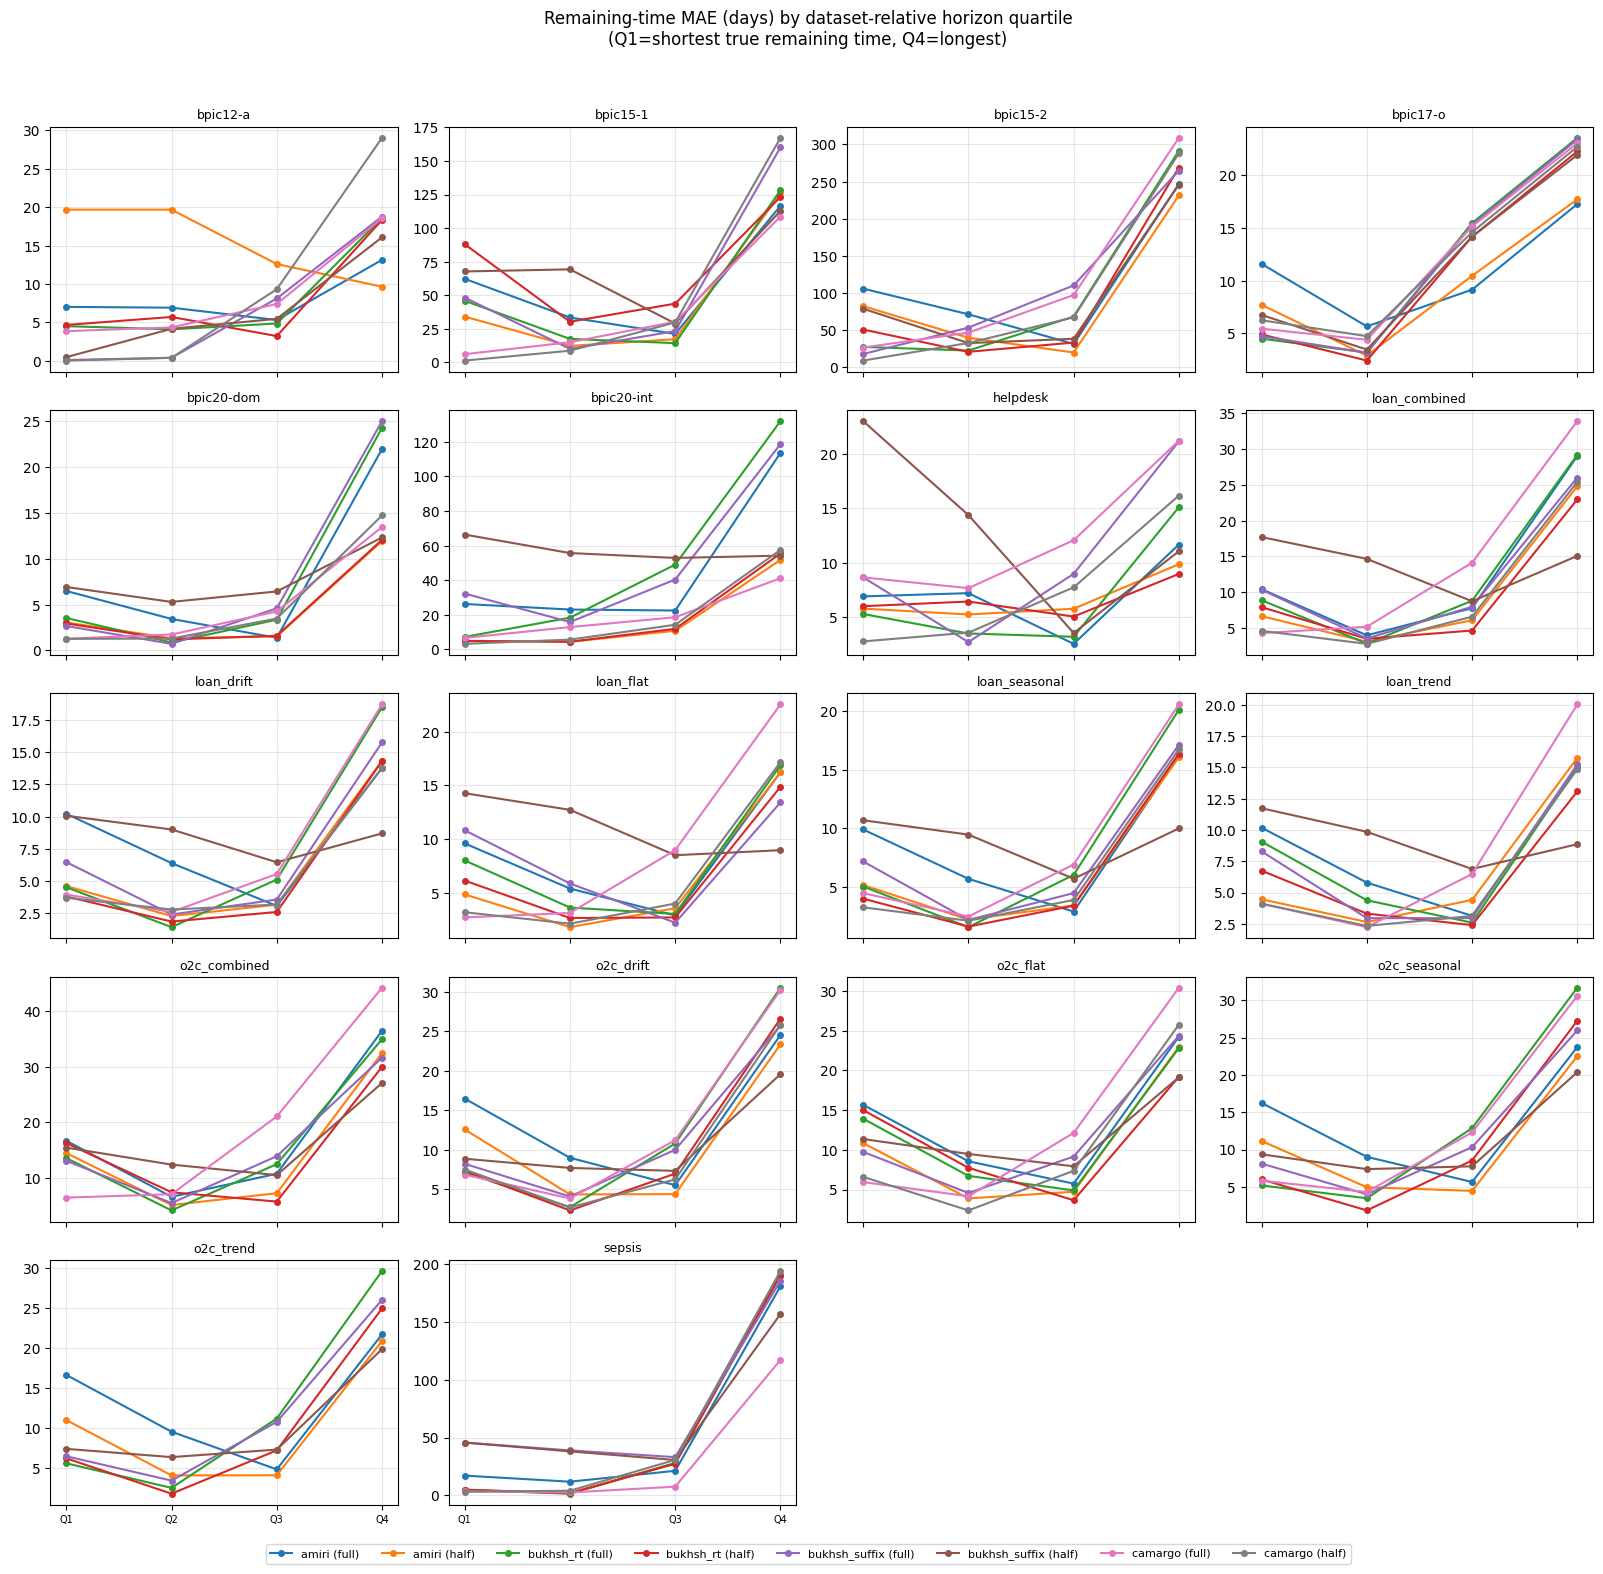

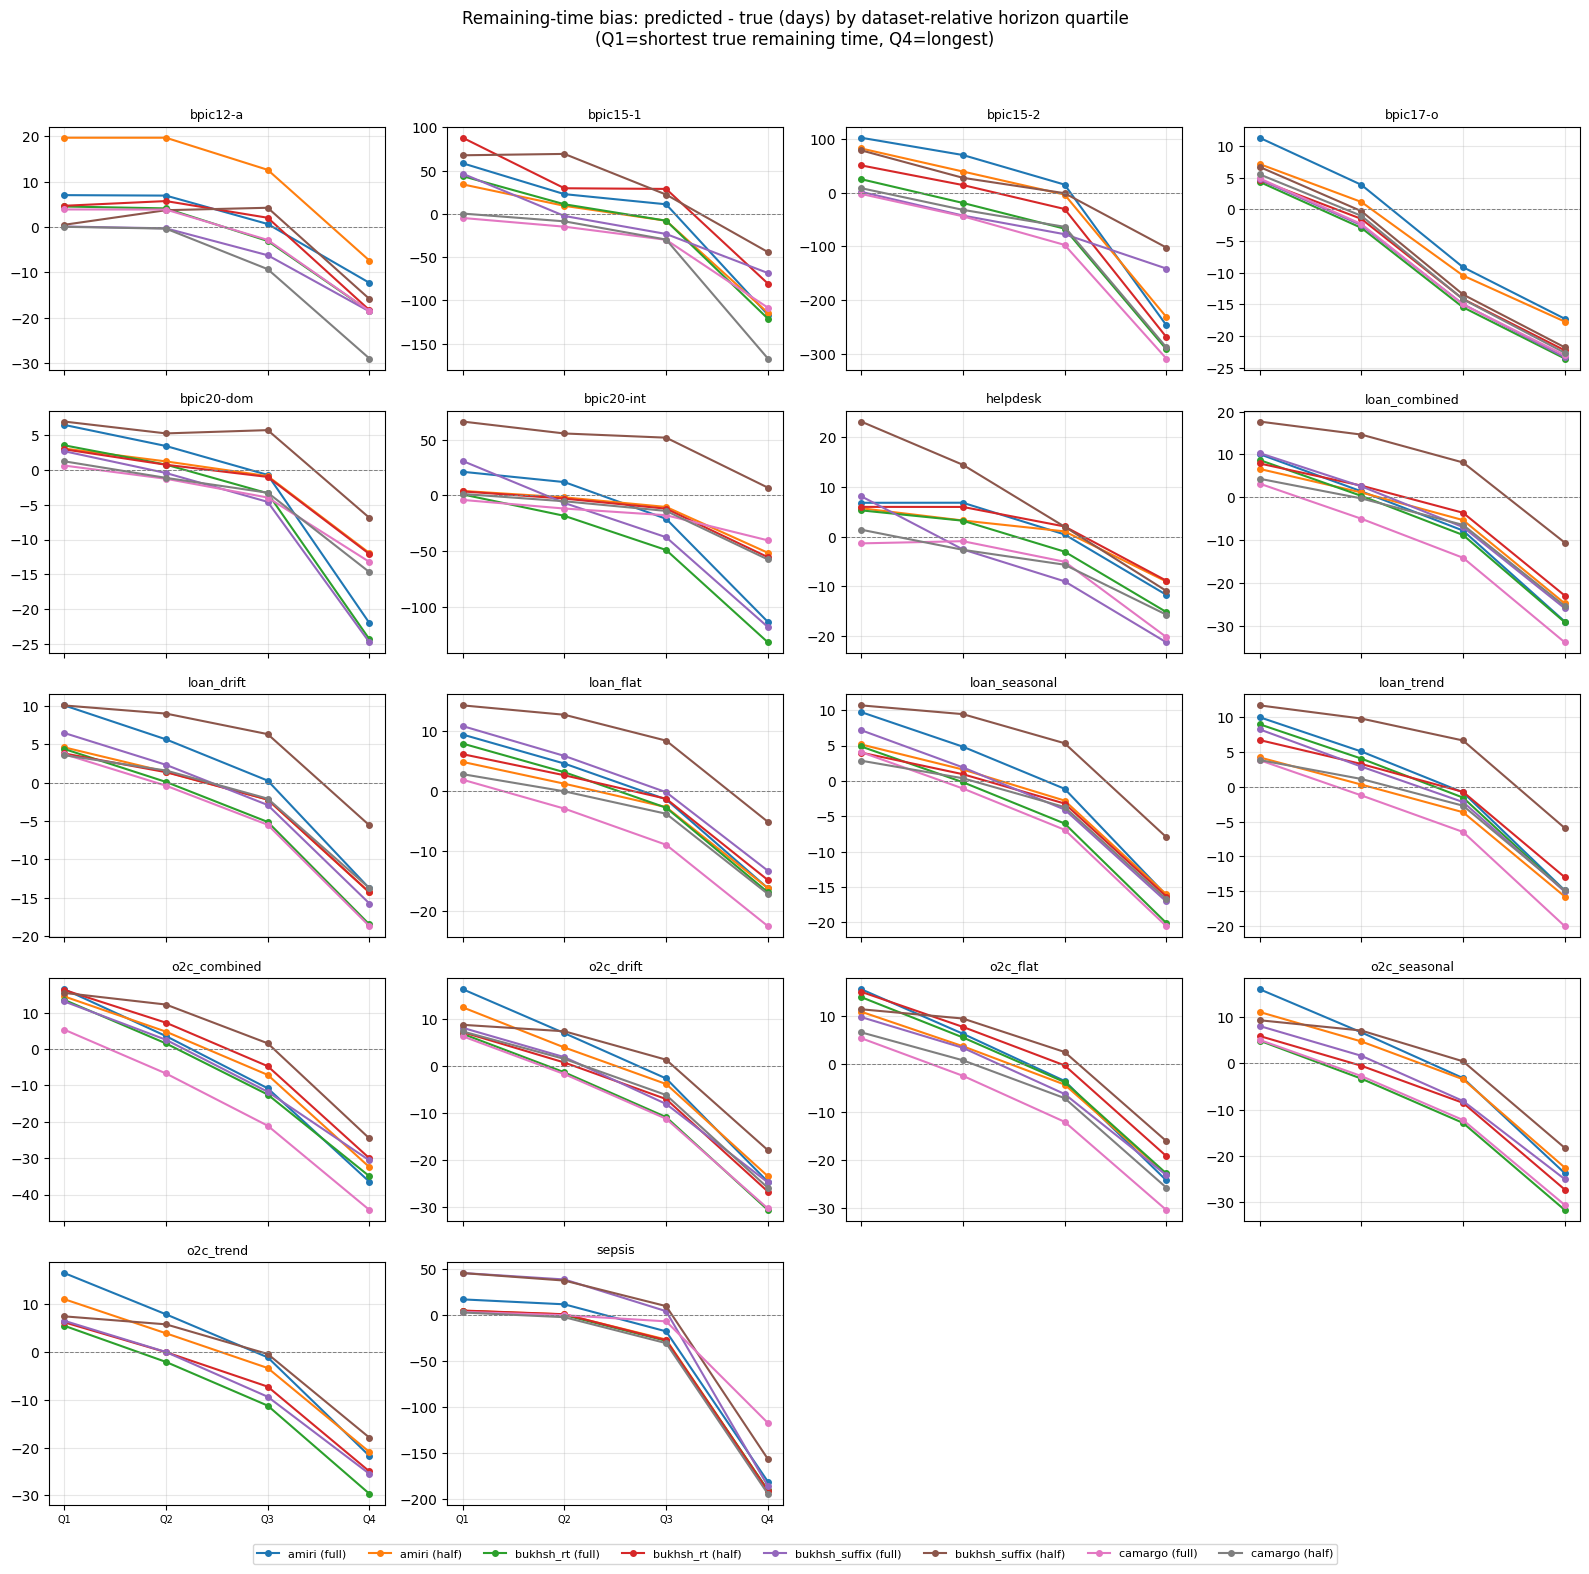

In [20]:
def plot_horizon_quartiles_grid(table, metric="mae", regimes=("full", "half"), ncols=4):
    datasets_present = sorted(table["dataset"].unique())
    n = len(datasets_present)
    nrows = -(-n // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharex=True)
    axes = axes.flatten()
    q_order = ["Q1", "Q2", "Q3", "Q4"]
    handles_labels = {}
    for ax, ds in zip(axes, datasets_present):
        sub = table[(table["dataset"] == ds) & (table["regime"].isin(regimes))]
        for (model, regime), g in sub.groupby(["model", "regime"]):
            g = g.set_index("horizon_q").reindex(q_order)
            line, = ax.plot(range(4), g[metric], marker="o", label=f"{model} ({regime})", markersize=4)
            handles_labels[f"{model} ({regime})"] = line
        if metric == "bias":
            ax.axhline(0, color="gray", lw=0.7, ls="--")
        ax.set_title(ds, fontsize=9)
        ax.set_xticks(range(4))
        ax.set_xticklabels(q_order, fontsize=7)
        ax.grid(alpha=0.3)
    for ax in axes[n:]:
        ax.axis("off")
    fig.legend(handles_labels.values(), handles_labels.keys(), loc="lower center",
              ncol=len(handles_labels), fontsize=8, bbox_to_anchor=(0.5, -0.02))
    metric_label = {"mae": "MAE (days)", "bias": "bias: predicted - true (days)", "std": "std of signed error (days)"}[metric]
    fig.suptitle(f"Remaining-time {metric_label} by dataset-relative horizon quartile\n(Q1=shortest true remaining time, Q4=longest)", y=1.02)
    plt.tight_layout()
    plt.show()


plot_horizon_quartiles_grid(horizon_table, metric="mae")
plot_horizon_quartiles_grid(horizon_table, metric="bias")


## 6. Case-count-weighted bias decomposition by prefix length -- why full's aggregate bias is smaller than half's

**Finding:** the per-prefix-length prediction curve is essentially
identical between full and half (same trained model) -- so a plain mean-bias-vs-pl
line chart, even split full/half, doesn't explain the gap; the two curves mostly
overlap. What actually differs is **which prefix_len buckets each regime's cases
fall into, and how many land in each one**.

So the CC-level gap is a **composition effect**: full's population happens to sit
mostly in the one bucket where the model is nearly unbiased; half's sits almost
entirely in the buckets where it's worst.

In [ ]:
def bias_contribution_table(model, ds, regimes=("full", "half")):
    """Per (regime, prefix_len): n_cases, mean signed bias (days), and their
    product -- the actual case-days contribution to the aggregate bias. Reuses
    remtime_df's already-computed signed_err_days (see cell 17) instead of
    reloading raw predictions."""
    sub = remtime_df[(remtime_df["model"] == model) & (remtime_df["dataset"] == ds)
                     & (remtime_df["regime"].isin(regimes))]
    g = (sub.groupby(["regime", "prefix_len"])["signed_err_days"]
        .agg(n_cases="size", mean_bias="mean", total_bias="sum").reset_index())
    return g.sort_values(["regime", "prefix_len"])


def plot_bias_contribution(model, ds, regimes=("full", "half"), max_prefix_len=15):
    """Two panels per regime: (left) mean bias/case as a line, n_cases as bars
    on a twin axis -- shows the curve is shared but the population isn't; (right)
    their product, mean_bias x n_cases -- the actual case-days contribution,
    colored green (offsets) / red (compounds). Net total annotated per regime."""
    table = bias_contribution_table(model, ds, regimes)
    table = table[table["prefix_len"] <= max_prefix_len]
    fig, axes = plt.subplots(len(regimes), 2, figsize=(13, 4 * len(regimes)))
    axes = axes.reshape(len(regimes), 2)
    for row, regime in zip(axes, regimes):
        g = table[table["regime"] == regime]
        if g.empty:
            continue

        ax = row[0]
        ax2 = ax.twinx()
        ax2.bar(g["prefix_len"], g["n_cases"], alpha=0.25, color="gray", label="n_cases")
        ax.plot(g["prefix_len"], g["mean_bias"], marker="o", color="C0")
        ax.axhline(0, color="black", lw=0.8)
        ax.set_title(f"{model}/{ds} ({regime}): mean bias & n_cases by prefix_len")
        ax.set_xlabel("prefix_len"); ax.set_ylabel("mean bias (days)", color="C0")
        ax2.set_ylabel("n_cases", color="gray")
        ax.set_xlim(left=0)

        ax = row[1]
        colors = ["crimson" if v < 0 else "seagreen" for v in g["total_bias"]]
        ax.bar(g["prefix_len"], g["total_bias"], color=colors)
        ax.axhline(0, color="black", lw=0.8)
        net = g["total_bias"].sum()
        ax.set_title(f"{model}/{ds} ({regime}): TOTAL bias contribution (mean x n)")
        ax.set_xlabel("prefix_len"); ax.set_ylabel("sum bias (case-days)")
        ax.text(0.98, 0.05, f"net = {net:,.0f} case-days", transform=ax.transAxes,
               ha="right", fontsize=9)
        ax.set_xlim(left=0)

    fig.suptitle(f"{ds} / {model}: case-count-weighted bias decomposition, {' vs '.join(regimes)}",
                fontsize=12)
    plt.tight_layout()
    plt.show()


for model in MODELS:
    plot_bias_contribution(model, "loan_flat")

### How general is this pattern? Net per-case bias, full vs half, all datasets x all 4 approaches (amiri, bukhsh_rt, bukhsh_suffix, camargo)

In [ ]:
def bias_contribution_summary():
    rows = []
    for model in MODELS:
        for ds in remtime_df.loc[remtime_df["model"] == model, "dataset"].unique():
            sub = remtime_df[(remtime_df["model"] == model) & (remtime_df["dataset"] == ds)
                             & (remtime_df["regime"].isin(["full", "half"]))]
            for regime in ["full", "half"]:
                rsub = sub[sub["regime"] == regime]
                if rsub.empty:
                    continue
                rows.append(dict(model=model, dataset=ds, regime=regime, n_cases=len(rsub),
                                 net_bias_per_case=rsub["signed_err_days"].mean()))
    return pd.DataFrame(rows)


bias_contrib_summary = bias_contribution_summary()
pivot = bias_contrib_summary.pivot_table(index=["model", "dataset"], columns="regime", values="net_bias_per_case")
pivot["half_more_biased"] = pivot["half"].abs() > pivot["full"].abs()
print(f"half's |net per-case bias| exceeds full's in {pivot['half_more_biased'].sum()}/{len(pivot)} (model, dataset) combos")
pivot.sort_values("half_more_biased", ascending=False).round(3)

In [ ]:
def aggregation_ratio_table(datasets, is_real):
    rows = []
    trim = "ssd" if is_real else "none"
    for ds in datasets:
        split = load_splits(ds, trim, is_real)
        tt_test = split["tt"]["test"]
        for model in REMTIME_MODELS:
            base = _amiri_base_dir(ds, trim, is_real) if model == "amiri" else _bukhsh_base_dir(ds, trim, is_real)
            p = base / "rem_time.csv"
            if not p.exists():
                continue
            rt = _read_csv_safe_caseid(p)
            case_end = true_case_end(ds, is_real)
            rtc = rt.copy()
            rtc["caseid"] = rtc["caseid"].astype(str)
            rtc["anchor_timestamp"] = pd.to_datetime(rtc["anchor_timestamp"], utc=True, format="mixed")
            rtc["true_end"] = rtc["caseid"].map(case_end)
            rtc = rtc.dropna(subset=["true_end"])
            rtc["true_rem_h"] = (rtc["true_end"] - rtc["anchor_timestamp"]).dt.total_seconds() / 3600
            rtc["pred_rem_h"] = rtc["rem_time_days"].astype(float) * 24
            percase_mae_h = (rtc["pred_rem_h"] - rtc["true_rem_h"]).abs().mean()

            event_log = _rem_time_to_event_log(rt)
            pred_tt_series = create_avg_throughtput_time_timeseries(event_log, time_col="end_timestamp", case_col="caseid", window="days", plot=False)
            pred_aligned = pred_tt_series.reindex(tt_test.index).ffill().bfill().fillna(0)
            daily_mae_h = mean_absolute_error(tt_test, pred_aligned)

            rows.append(dict(dataset=ds, model=model,
                             percase_mae_days=percase_mae_h / 24, daily_mae_days=daily_mae_h / 24,
                             ratio=(percase_mae_h / daily_mae_h) if daily_mae_h > 0 else np.nan))
    return pd.DataFrame(rows)


agg_ratio_table = pd.concat([
    aggregation_ratio_table(SYNTH_DATASETS, False),
    aggregation_ratio_table(REAL_DATASETS, True),
], ignore_index=True)
agg_ratio_table.round(2).sort_values("ratio")


## 7. Exact mathematical function: trace-level day-error -> CC MAE

This section derives and verifies the exact function behind
that ratio, per the idea that CC error on a given day is just "how many
traces are wrong about being active/inactive on that day."

**Setup.** Every case shares the same (known, real) start day. Let
`tau_i` = floor(true_end_i, day), `pi_i` = floor(pred_end_i, day) --
`create_concurrent_cases_timeseries` counts a case active on a CLOSED
interval `[start_bucket, end_bucket]` (both ends inclusive).
So for a single case, the days where predicted and true disagree are exactly
`(min(tau_i, pi_i), max(tau_i, pi_i)]` -- exclusive at the smaller bucket,
inclusive at the larger one -- and the case contributes:

```
delta_i(d) = +1  if tau_i < d <= pi_i   (over-predicted: wrongly counted active)
           = -1  if pi_i  < d <= tau_i  (under-predicted: wrongly counted ended)
           =  0  otherwise
```

**CC error on day d** = `sum_i delta_i(d)` = `CC_pred(d) - CC_true(d)`.

**Two exact consequences**:

1. **Bias identity**: summing `delta_i(d)` over all days recovers exactly the
  per-case day-bias, so `mean_signed_CC_error = (1/T) * sum_i (pi_i - tau_i)`
  -- the average signed CC error is *exactly* the average per-case day-bias.
2. **MAE inequality**: `CC_MAE = (1/T) * sum_d |sum_i delta_i(d)|` <=
  `(1/T) * sum_i |pi_i - tau_i|` (triangle inequality) -- equality holds
  exactly when every day's disagreeing cases all share the same sign (no
  cross-case cancellation).

In [ ]:
def daily_disagreement(rt_df, test_index):
    # Per test day: sum over cases of delta_i(d) -- exact CC disagreement,
    # day by day, from trace-level (predicted_end, true_end) pairs alone.
    # rt_df needs columns pred_end, true_end (both tz-naive Timestamps).
    err = pd.Series(0.0, index=test_index)
    for _, row in rt_df.iterrows():
        pred_b, true_b = row["pred_end"].normalize(), row["true_end"].normalize()
        if pred_b == true_b:
            continue
        sign = 1.0 if pred_b > true_b else -1.0
        lo, hi = min(pred_b, true_b), max(pred_b, true_b)
        mask = (test_index > lo) & (test_index <= hi)
        err.loc[mask] += sign
    return err


def verify_trace_to_cc_function(model, ds, regime, is_real=False, trim=None):
    # Builds rt_df (predicted_end/true_end per case) for one (model, dataset,
    # regime), runs daily_disagreement(), and compares its MAE/bias against the
    # project's established create_concurrent_cases_timeseries + reindex/ffill/bfill
    # pipeline -- should match to machine precision when case coverage is identical.
    trim = trim or ("ssd" if is_real else "none")
    split = load_splits(ds, trim, is_real)
    cc_test = split["cc"]["test"]
    base = _amiri_base_dir(ds, trim, is_real) if model == "amiri" else _bukhsh_base_dir(ds, trim, is_real)
    p = _rem_time_path(base, regime)
    if not p.exists():
        return None
    rt = _read_csv_safe_caseid(p)
    rt["caseid"] = rt["caseid"].astype(str)
    rt["start_timestamp"] = pd.to_datetime(rt["start_timestamp"], utc=True, format="mixed").dt.tz_convert(None)
    rt["anchor_timestamp"] = pd.to_datetime(rt["anchor_timestamp"], utc=True, format="mixed").dt.tz_convert(None)
    rt["pred_end"] = rt["anchor_timestamp"] + pd.to_timedelta(rt["rem_time_days"].astype(float), unit="D")
    case_end_true = pd.to_datetime(split["df"].groupby("caseid")["end_timestamp"].max(), utc=True).dt.tz_convert(None)
    case_end_true.index = case_end_true.index.astype(str)
    rt["true_end"] = rt["caseid"].map(case_end_true)
    rt = rt.dropna(subset=["true_end"])

    test_index = pd.DatetimeIndex(cc_test.index)
    err_series = daily_disagreement(rt, test_index)
    derived_bias, derived_mae = err_series.mean(), err_series.abs().mean()

    event_log = _rem_time_to_event_log(rt)
    pred_cc = create_concurrent_cases_timeseries(event_log, time_col="end_timestamp", case_col="caseid", window="days", plot=False)
    pred_aligned = pred_cc.reindex(cc_test.index).ffill().bfill().fillna(0)
    recorded_mae = mean_absolute_error(cc_test, pred_aligned)
    recorded_bias = (pred_aligned - cc_test).mean()

    per_case_bias_days = (rt["pred_end"] - rt["true_end"]).dt.total_seconds() / 86400
    upper_bound_mae = per_case_bias_days.abs().sum() / len(test_index)

    return dict(model=model, dataset=ds, regime=regime,
               derived_bias=derived_bias, recorded_bias=recorded_bias,
               derived_mae=derived_mae, recorded_mae=recorded_mae,
               bias_match=np.isclose(derived_bias, recorded_bias),
               mae_match=np.isclose(derived_mae, recorded_mae),
               upper_bound_mae=upper_bound_mae,
               cancellation_ratio=upper_bound_mae / derived_mae if derived_mae > 0 else np.nan)


trace_to_cc_checks = []
for model, ds in [("amiri", "loan_flat"), ("bukhsh_rt", "loan_drift")]:
    for regime in ("full", "half"):
        r = verify_trace_to_cc_function(model, ds, regime)
        if r is not None:
            trace_to_cc_checks.append(r)

trace_to_cc_df = pd.DataFrame(trace_to_cc_checks)
print(f"all bit-exact: bias_match={trace_to_cc_df['bias_match'].all()}  mae_match={trace_to_cc_df['mae_match'].all()}")
trace_to_cc_df.round(4)